# PolyFit vs BEM — per-segment

Plots behind [Polyfit-comparison.md](Polyfit-comparison.md). **Base models only**, no residual net:
`polyfit_paper` (Sun/de Visser/Chu gray-box, 3 bins) against `bem_default` (untuned BEM), on the
13 pinned `paper/test` segments.

RMSE per segment is the paper's collapsed form, `F = sqrt(mean(Fx²,Fy²,Fz²))` and the same for `M`
([metrics.py](../../MyBEM/mybem/metrics.py)). Measured wrench from
[Drone.measured](../../MyBEM/mybem/drone.py), predictions read from `store/preds/<name>@<hash>/`.

Kernel: `mybem`. Needs both bases applied — `mybem-apply configs/models/{polyfit_paper,bem_default}.yaml`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "MyBEM").exists())
sys.path.insert(0, str(ROOT / "MyBEM"))

from mybem.columns import LINVEL, load
from mybem.data import preds_dir, read_preds, segment_ids, split
from mybem.drone import Drone
from mybem.metrics import table

MODELS = {"polyfit": "polyfit_paper", "bem": "bem_default"}
COLOR = {"measured": "#000000", "polyfit": "#0072B2", "bem": "#D55E00"}
CHANNELS = ["fx", "fy", "fz", "tx", "ty", "tz"]

ids = split("paper", segment_ids())["test"]
drone = Drone.load("paper_quad")
{k: preds_dir(v).name for k, v in MODELS.items()}

{'polyfit': 'polyfit_paper@4ad993', 'bem': 'bem_default@4bf0d0'}

In [2]:
seg = {}
for sid in ids:
    d = load(sid)
    fm, tm = drone.measured(d)
    s = {"t": d[:, 0], "meas": np.hstack([fm, tm]),
         "vmax": np.linalg.norm(d[:, LINVEL], axis=1).max()}
    for k, name in MODELS.items():
        s[k] = read_preds(preds_dir(name), sid, d)
        res = s["meas"] - s[k]
        s[f"F_{k}"], s[f"M_{k}"] = table(res[:, :3], res[:, 3:])[2::3]
    seg[sid] = s

rmse = pd.DataFrame({sid: {"vmax": s["vmax"], "n": len(s["t"]),
                          **{f"{m}_{k}": s[f"{m}_{k}"] for m in "FM" for k in MODELS}}
                     for sid, s in seg.items()}).T.sort_values("vmax")
rmse["F ratio"] = rmse["F_bem"] / rmse["F_polyfit"]
rmse["M ratio"] = rmse["M_bem"] / rmse["M_polyfit"]
rmse.style.format("{:.3f}", subset=["vmax", "F_polyfit", "F_bem", "F ratio", "M ratio"]) \
          .format("{:.4f}", subset=["M_polyfit", "M_bem"]).format("{:.0f}", subset=["n"])

,vmax,n,F_polyfit,F_bem,M_polyfit,M_bem,F ratio,M ratio
2021-02-23-10-48-03_seg_2,3.455,11749,0.110,0.119,0.0030,0.0260,1.080,8.725
2021-02-18-17-03-20_seg_2,6.516,14306,0.136,0.316,0.0043,0.0401,2.332,9.336
2021-02-23-11-41-38_seg_3,6.802,11431,0.180,0.438,0.0055,0.0498,2.430,9.104
2021-02-23-22-26-25_seg_2,8.824,42265,0.532,0.701,0.0148,0.0454,1.318,3.063
2021-02-18-13-44-23_seg_2,9.693,16797,0.275,0.594,0.0068,0.0849,2.157,12.540
2021-02-18-17-19-08_seg_2,11.264,12724,0.569,0.789,0.0125,0.0861,1.387,6.905
2021-02-18-18-08-45_seg_1,11.810,15626,0.375,0.827,0.0088,0.1205,2.207,13.658
2021-02-23-19-45-06_seg_2,12.150,23390,0.738,0.941,0.0128,0.1401,1.275,10.959
2021-02-23-14-21-48_seg_3,13.609,14784,0.541,1.328,0.0151,0.1138,2.457,7.541
2021-02-18-17-26-00_seg_1,14.261,10452,0.628,1.327,0.0196,0.1260,2.113,6.437


## RMSE vs segment max speed

Ratio > 1 means PolyFit wins that segment.

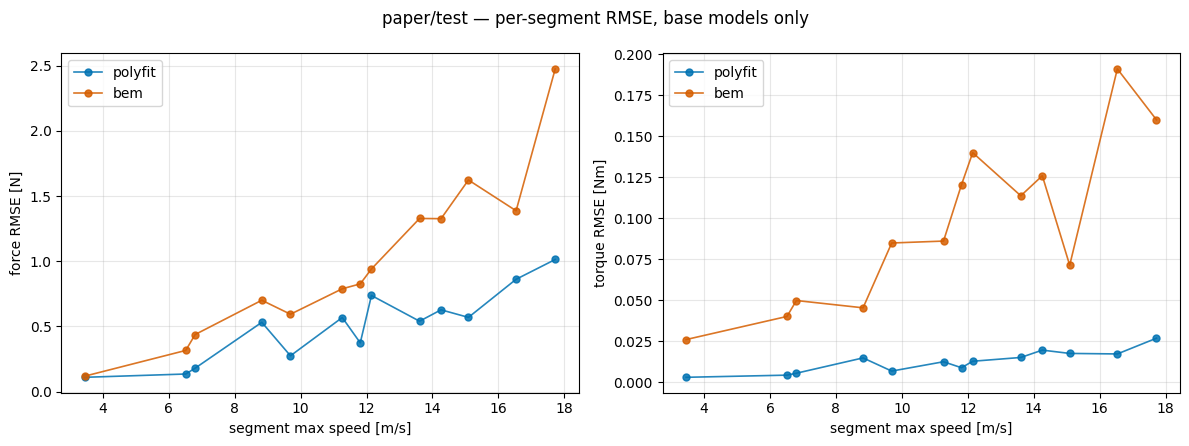

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, m, unit in [(ax[0], "F", "force RMSE [N]"), (ax[1], "M", "torque RMSE [Nm]")]:
    for k in MODELS:
        a.plot(rmse["vmax"], rmse[f"{m}_{k}"], "o-", color=COLOR[k], lw=1.2, ms=5,
               alpha=0.85, label=k)
    a.set(xlabel="segment max speed [m/s]", ylabel=unit)
    a.grid(alpha=0.3)
    a.legend()
fig.suptitle("paper/test — per-segment RMSE, base models only")
fig.tight_layout()

## Best and worst segments

Extremes of each model's own force and torque RMSE, one model per figure. A segment picked
by both criteria of the same model is plotted once.

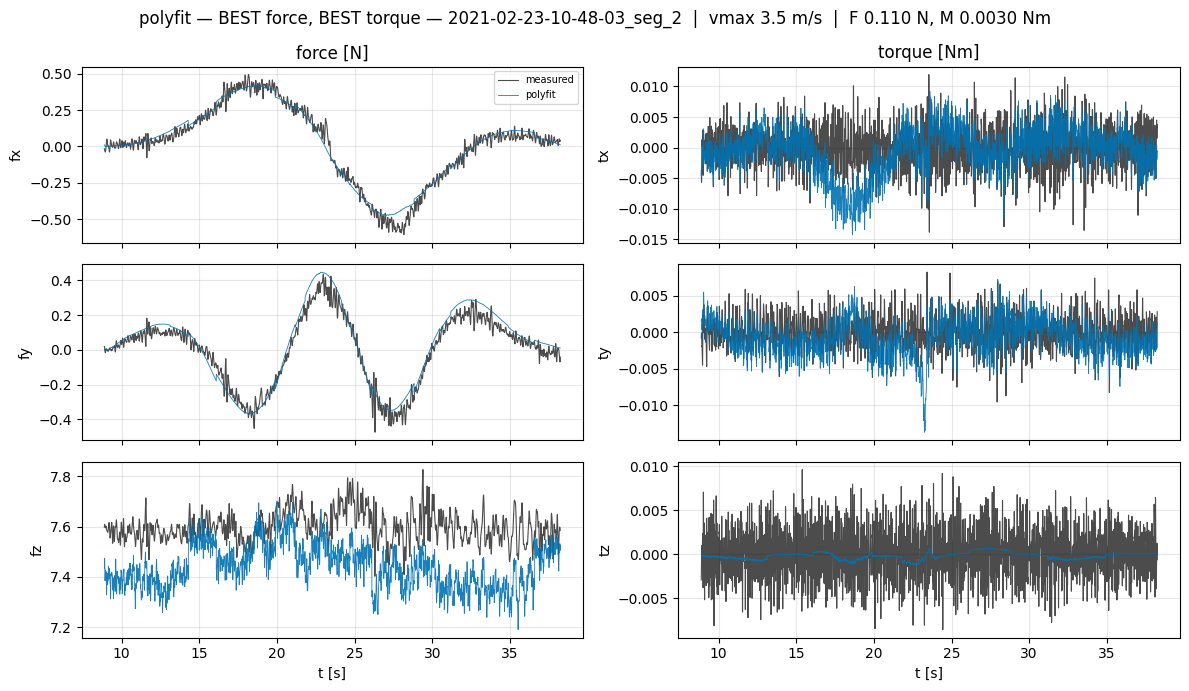

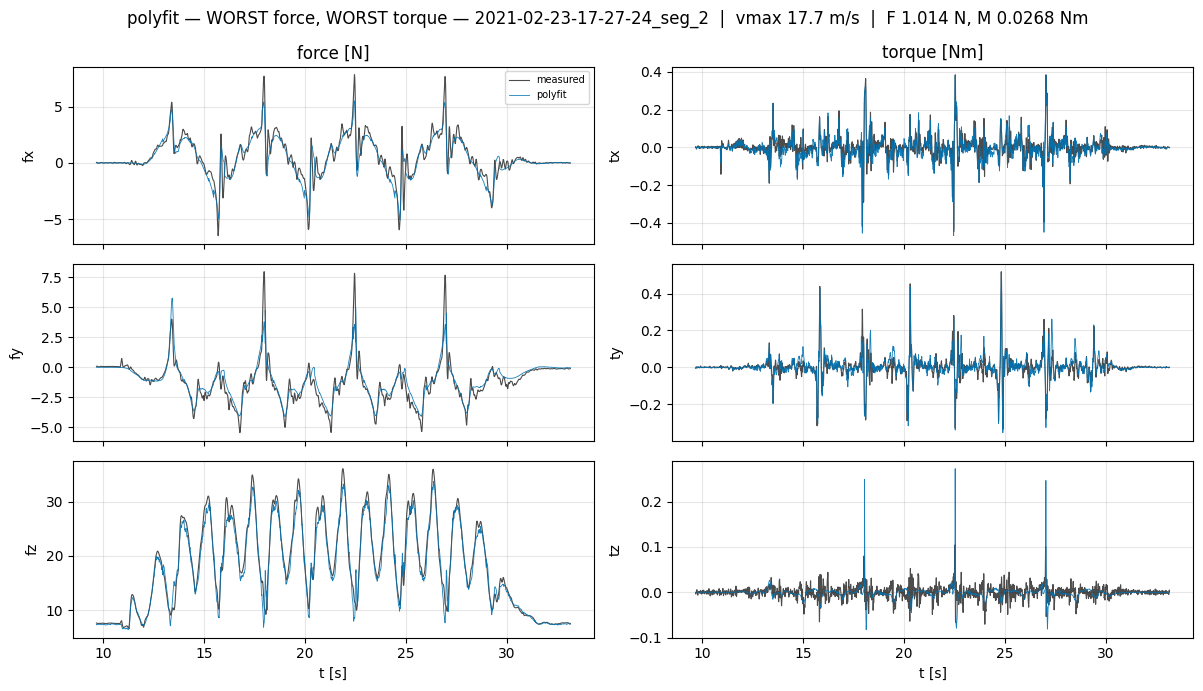

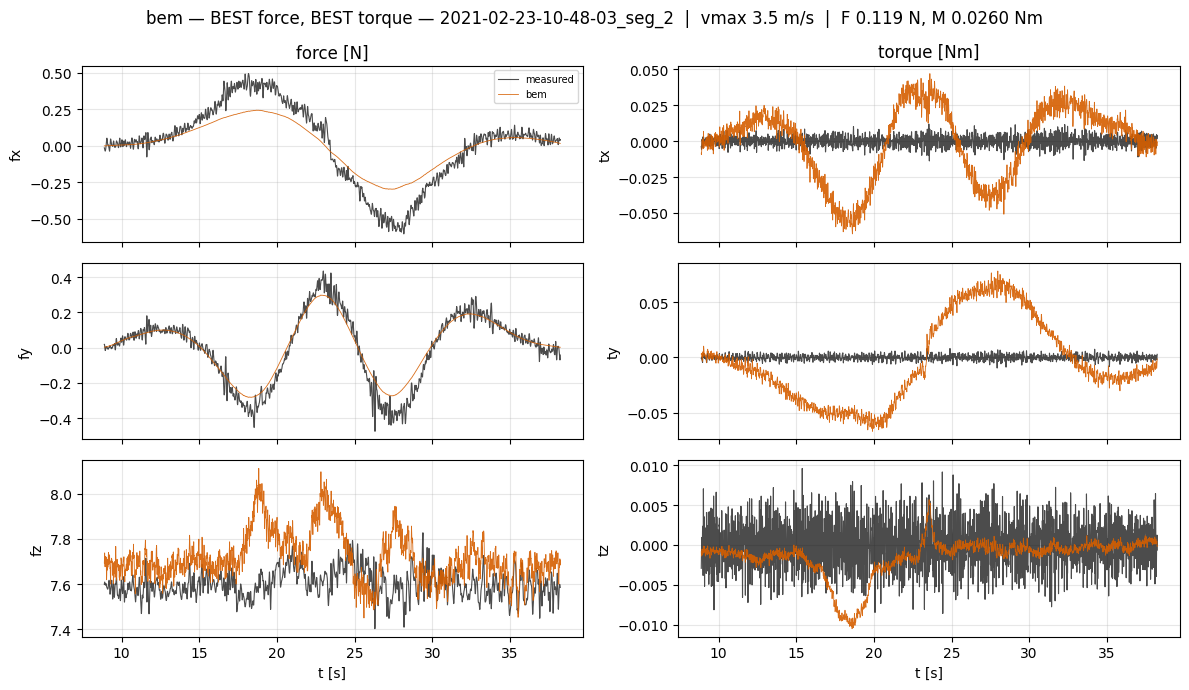

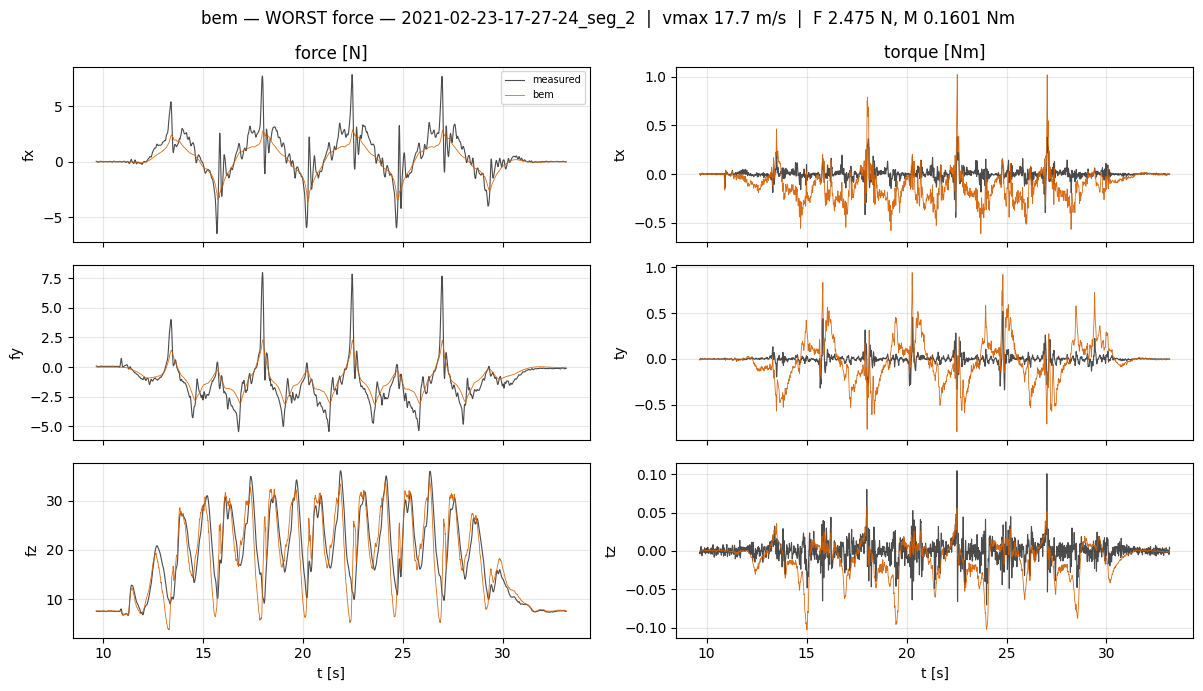

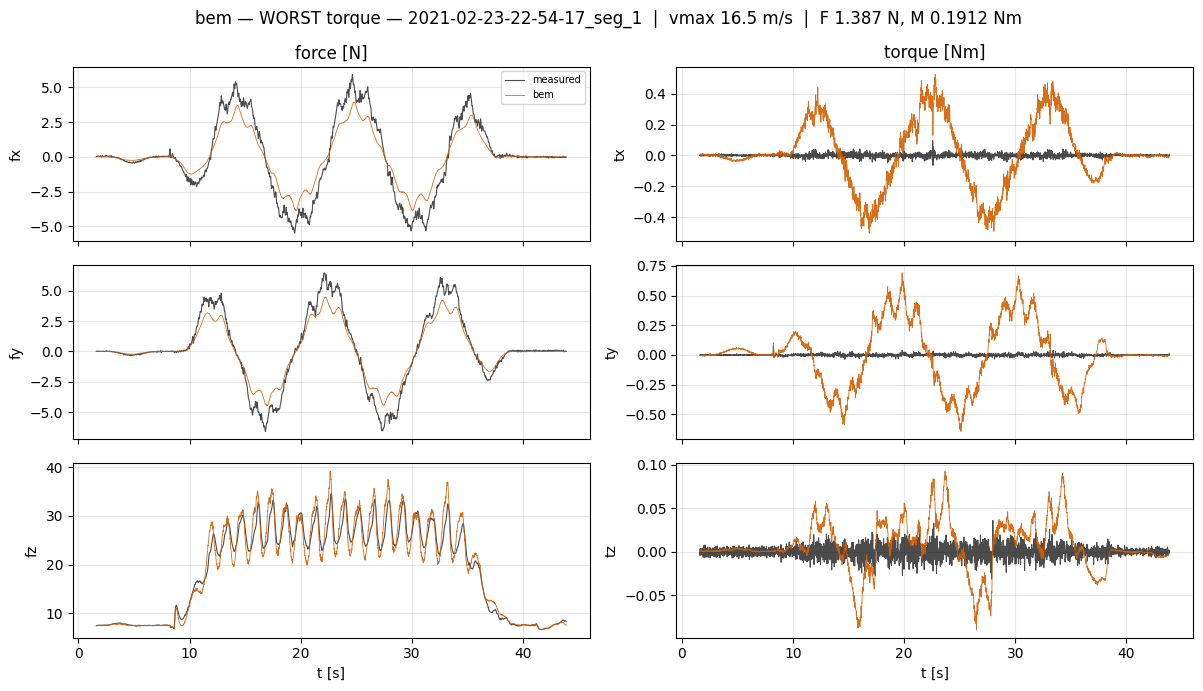

In [5]:
def plot_seg(sid, k, tag):
    s = seg[sid]
    fig, ax = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
    for i, c in enumerate(CHANNELS):
        a = ax[i % 3, i // 3]
        a.plot(s["t"], s["meas"][:, i], lw=0.8, alpha=0.7, color=COLOR["measured"],
               label="measured")
        a.plot(s["t"], s[k][:, i], lw=0.6, alpha=0.9, color=COLOR[k], label=k)
        a.set_ylabel(c)
        a.grid(alpha=0.3)
    ax[0, 0].set_title("force [N]")
    ax[0, 1].set_title("torque [Nm]")
    ax[2, 0].set_xlabel("t [s]")
    ax[2, 1].set_xlabel("t [s]")
    ax[0, 0].legend(loc="upper right", fontsize=7)
    fig.suptitle(f"{k} — {tag} — {sid}  |  vmax {s['vmax']:.1f} m/s  |  "
                 f"F {s[f'F_{k}']:.3f} N, M {s[f'M_{k}']:.4f} Nm")
    fig.tight_layout()


for k in MODELS:
    picks = {}
    for m, lbl in [("F", "force"), ("M", "torque")]:
        col = rmse[f"{m}_{k}"]
        picks.setdefault(col.idxmin(), []).append(f"BEST {lbl}")
        picks.setdefault(col.idxmax(), []).append(f"WORST {lbl}")
    for sid, tags in picks.items():
        plot_seg(sid, k, ", ".join(tags))